=== Performance Comparison ===
Bagging Classifier Accuracy: 0.9400
Random Forest Accuracy:      0.9333

Bagging Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       147
           1       0.96      0.92      0.94       153

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       147
           1       0.95      0.92      0.93       153

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



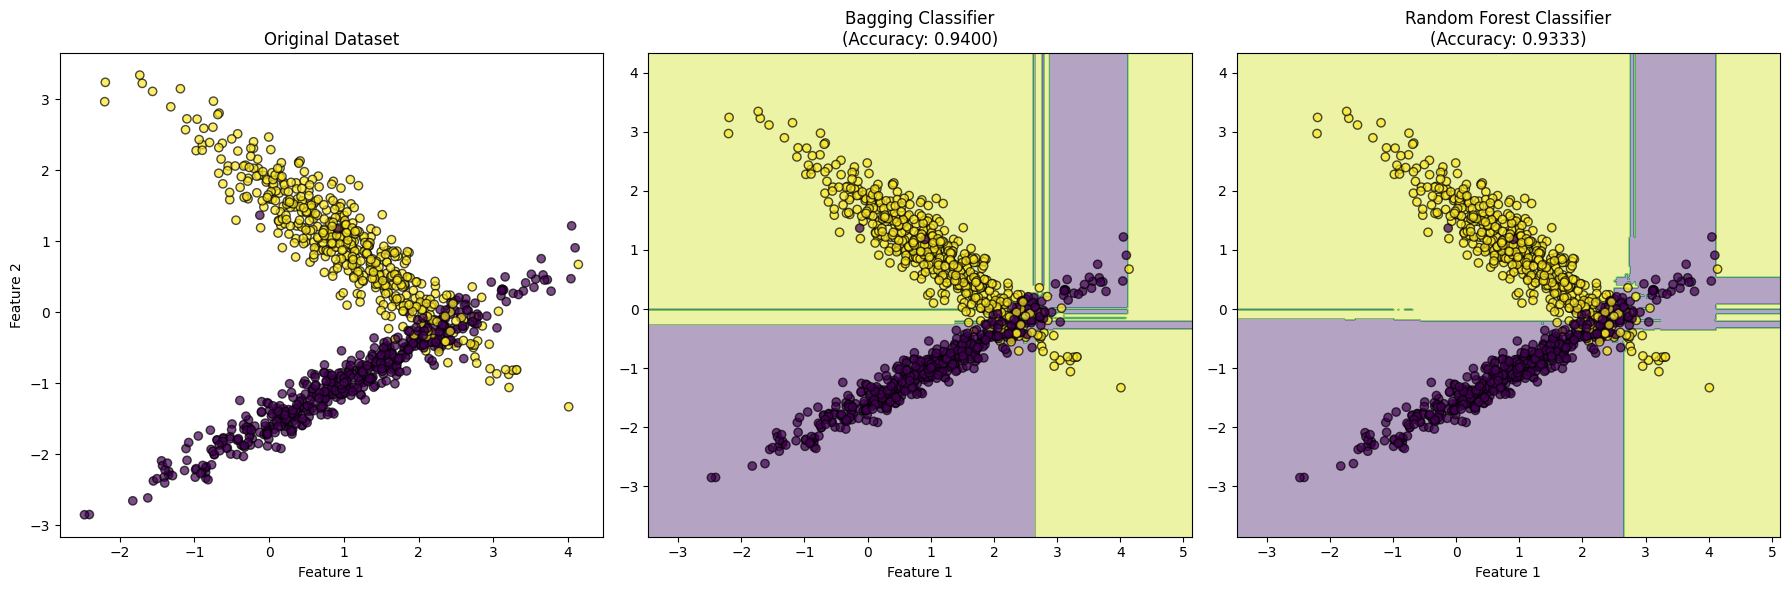


Random Forest Feature Importances: [0.17206422 0.82793578]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

# Generate a classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize classifiers
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train both models
bagging_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_bagging = bagging_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Evaluate performance
acc_bagging = accuracy_score(y_test, y_pred_bagging)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== Performance Comparison ===")
print(f"Bagging Classifier Accuracy: {acc_bagging:.4f}")
print(f"Random Forest Accuracy:      {acc_rf:.4f}")
print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bagging))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# =============== Visualization ===============

# Create mesh grid for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for mesh
Z_bagging = bagging_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rf = rf_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_bagging = Z_bagging.reshape(xx.shape)
Z_rf = Z_rf.reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Original Data
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
axes[0].set_title('Original Dataset')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Plot 2: Bagging Decision Boundary
axes[1].contourf(xx, yy, Z_bagging, alpha=0.4, cmap='viridis')
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
axes[1].set_title(f'Bagging Classifier\n(Accuracy: {acc_bagging:.4f})')
axes[1].set_xlabel('Feature 1')

# Plot 3: Random Forest Decision Boundary
axes[2].contourf(xx, yy, Z_rf, alpha=0.4, cmap='viridis')
axes[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
axes[2].set_title(f'Random Forest Classifier\n(Accuracy: {acc_rf:.4f})')
axes[2].set_xlabel('Feature 1')

plt.tight_layout()
plt.show()

# Optional: Feature Importance (only available in Random Forest)
importances = rf_clf.feature_importances_
print(f"\nRandom Forest Feature Importances: {importances}")

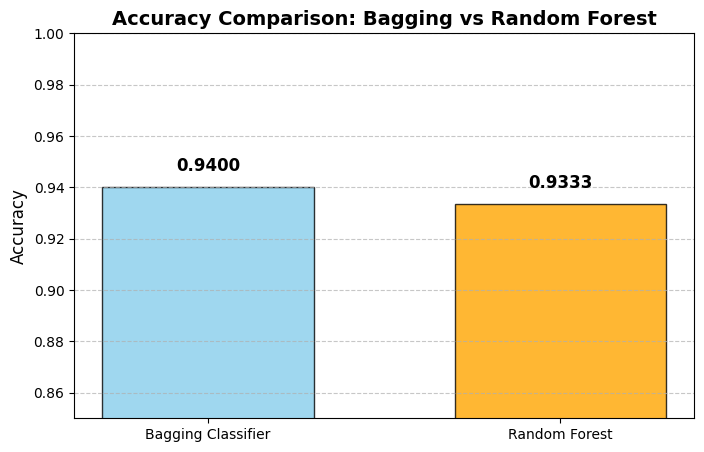

In [2]:
plt.figure(figsize=(8, 5))

# Data for bar graph
models = ['Bagging Classifier', 'Random Forest']
accuracies = [acc_bagging, acc_rf]
colors = ['skyblue', 'orange']

# Create bar plot
bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Add accuracy labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Accuracy Comparison: Bagging vs Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.85, 1.0)                    # Zoom into high accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Dataset Shape: (2000, 10)
Training Samples: 1400, Test Samples: 600

🔍 Testing Hyperparameters One by One...

n_estimators =  50 → Accuracy: 0.8433
n_estimators = 100 → Accuracy: 0.8467
n_estimators = 200 → Accuracy: 0.8483
n_estimators = 300 → Accuracy: 0.8517
max_features = sqrt → Accuracy: 0.8467
max_features = log2 → Accuracy: 0.8467
max_features = None → Accuracy: 0.8500
max_depth = None → Accuracy: 0.8467
max_depth = 10 → Accuracy: 0.8300
max_depth = 20 → Accuracy: 0.8450
max_depth = 30 → Accuracy: 0.8467


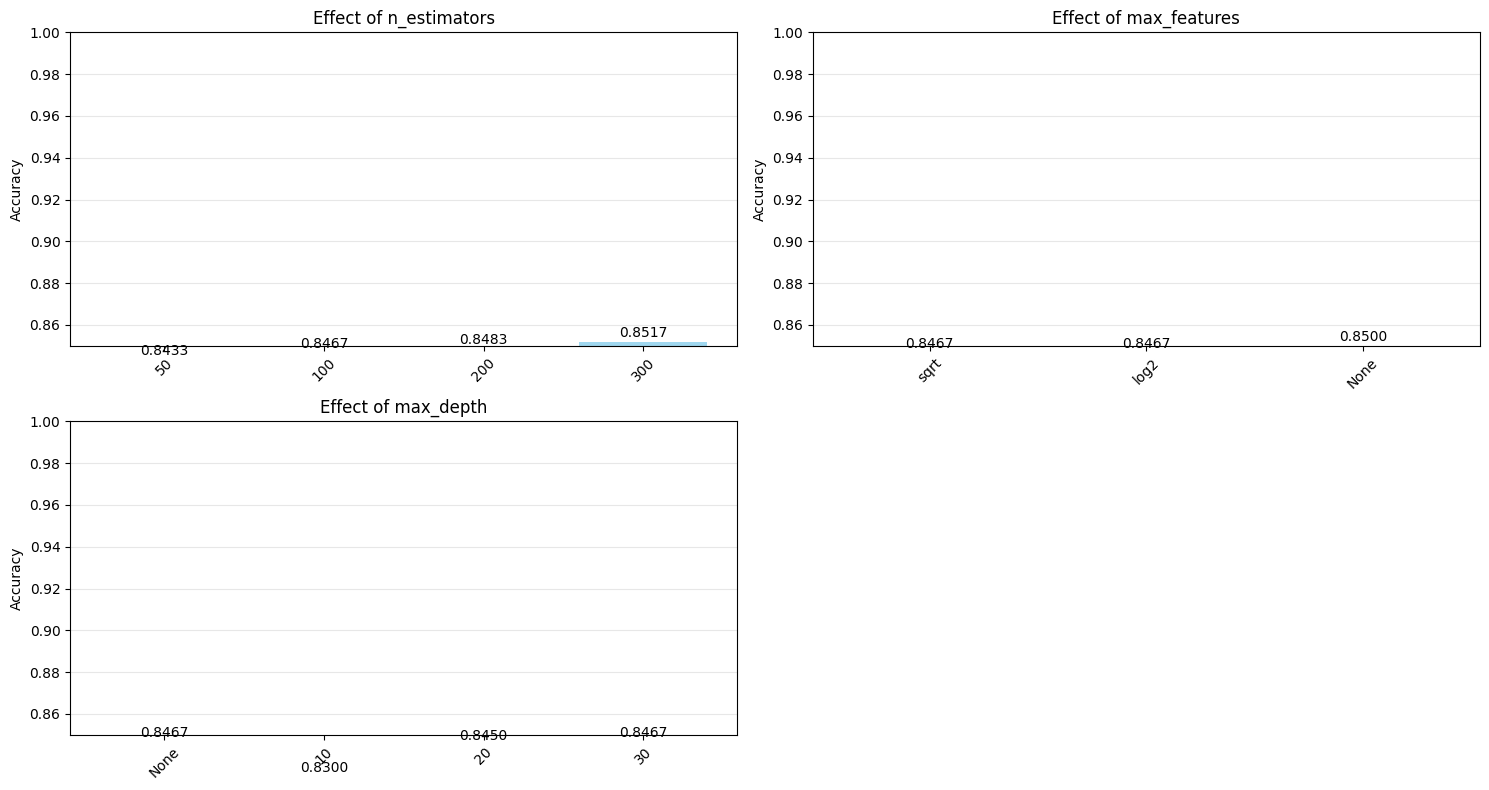


🔍 Running GridSearchCV for Best Hyperparameters...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best Cross-Validation Accuracy: 0.8736
✅ Test Set Accuracy with Best Model: 0.8433

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       295
           1       0.86      0.83      0.84       305

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



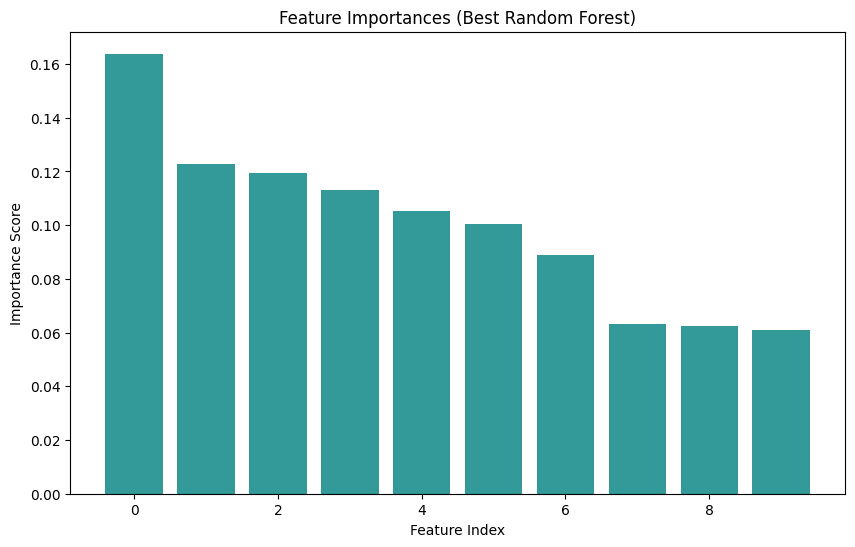

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ====================== 1. Load Dataset ======================
# Using make_classification for better control (you can change to real dataset)
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

# Alternative: Real dataset
# data = load_breast_cancer()
# X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset Shape: {X.shape}")
print(f"Training Samples: {X_train.shape[0]}, Test Samples: {X_test.shape[0]}\n")

# ====================== 2. Define Hyperparameters to Test ======================
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# ====================== 3. Function to Test Individual Hyperparameters ======================
def test_hyperparameters():
    results = []
    base_params = {'random_state': 42, 'n_jobs': -1}

    print("🔍 Testing Hyperparameters One by One...\n")

    # Test n_estimators
    for n in [50, 100, 200, 300]:
        clf = RandomForestClassifier(n_estimators=n, **base_params)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        results.append({'Parameter': 'n_estimators', 'Value': n, 'Accuracy': acc})
        print(f"n_estimators = {n:3d} → Accuracy: {acc:.4f}")

    # Test max_features
    for feat in ['sqrt', 'log2', None]:
        clf = RandomForestClassifier(max_features=feat, **base_params)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        results.append({'Parameter': 'max_features', 'Value': feat, 'Accuracy': acc})
        print(f"max_features = {feat} → Accuracy: {acc:.4f}")

    # Test max_depth
    for depth in [None, 10, 20, 30]:
        clf = RandomForestClassifier(max_depth=depth, **base_params)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        results.append({'Parameter': 'max_depth', 'Value': depth, 'Accuracy': acc})
        print(f"max_depth = {depth} → Accuracy: {acc:.4f}")

    return pd.DataFrame(results)

# ====================== 4. Run Individual Tests ======================
df_results = test_hyperparameters()

# ====================== 5. Bar Plot for Hyperparameter Comparison ======================
plt.figure(figsize=(15, 8))

# Group by parameter
params = df_results['Parameter'].unique()

for i, param in enumerate(params):
    subset = df_results[df_results['Parameter'] == param]
    plt.subplot(2, 2, i+1)
    bars = plt.bar(subset['Value'].astype(str), subset['Accuracy'], color='skyblue', alpha=0.8)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=10)

    plt.title(f'Effect of {param}')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0.85, 1.0)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ====================== 6. GridSearchCV - Best Combination ======================
print("\n" + "="*60)
print("🔍 Running GridSearchCV for Best Hyperparameters...")
print("="*60)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Reduced grid for faster execution (you can expand it)
reduced_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=reduced_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Final Model Evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f"✅ Test Set Accuracy with Best Model: {final_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ====================== 7. Feature Importance from Best Model ======================
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Best Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], color='teal', alpha=0.8)
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()